# Amazon Multi-Domain Review Sentiment Analysis

**Author:** Nguyễn Thị Việt Thương
**Portfolio piece 2/2 — Machine Learning project**

## Business context

An online retailer selling across multiple product categories receives thousands of
customer reviews every month. A customer-support or product team cannot manually read
every review to know which products are causing dissatisfaction, or what customers are
specifically complaining about. This project builds an automated pipeline that classifies
review sentiment (negative / neutral / positive) directly from review text, and surfaces
the specific keywords driving negative sentiment in each product category — the kind of
"market/consumer intelligence" a business analyst would want to hand to a category manager.

## Research questions

1. Can review sentiment (negative / neutral / positive) be predicted from review text
   with acceptable accuracy, using a classic and interpretable NLP pipeline (TF-IDF +
   classical ML), without needing modern embeddings?
2. Which keywords are most characteristic of each sentiment class, and does this differ
   by product category?
3. Which product category (book / electronics / beauty) has the highest rate of negative
   reviews, and what do the reviews say is driving that?

## Data source

- **Original source:** [`goosmanlei/amazon_reviews_multi`](https://huggingface.co/datasets/goosmanlei/amazon_reviews_multi)
  on Hugging Face — English subset of a multilingual Amazon product review dataset
  (1★–5★ ratings).
- **Working file used here:** a cleaned/filtered version (Kaggle: *Cleaned Amazon
  Multi Domain Review Dataset*) that (a) keeps English-language reviews only,
  (b) restricts to three balanced product categories — `book`, `electronics`, `beauty`
  (3,756 reviews each), and (c) converts the 1★–5★ rating into a 3-class sentiment
  label: **0 = negative, 1 = neutral, 2 = positive** (confirmed manually below by
  reading sample reviews per label).
- All text preprocessing, TF-IDF vectorization, modeling, and evaluation shown below
  were performed by me on top of this already-prepared file.


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)
from nltk.stem import PorterStemmer

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42


In [ ]:
df = pd.read_csv("cleaned_amazon_multi_domain_reviews.csv")
print("Shape:", df.shape)
df.info()


Shape: (11268, 10)
<class 'pandas.DataFrame'>
RangeIndex: 11268 entries, 0 to 11267
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   review_id           11268 non-null  str  
 1   product_id          11268 non-null  str  
 2   reviewer_id         11268 non-null  str  
 3   label               11268 non-null  int64
 4   review_body         11268 non-null  str  
 5   review_title        11268 non-null  str  
 6   language            11268 non-null  str  
 7   product_category    11268 non-null  str  
 8   model_input         11268 non-null  str  
 9   model_input_length  11268 non-null  int64
dtypes: int64(2), str(8)
memory usage: 6.1 MB


## 1. Exploratory Data Analysis

           count   pct
sentiment             
positive    5532  49.1
negative    3360  29.8
neutral     2376  21.1


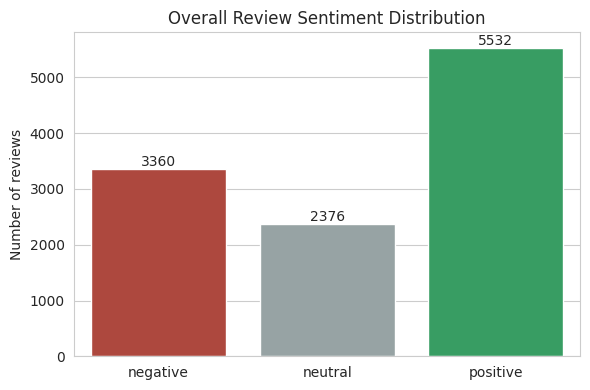

In [ ]:
# 1.1 Overall label distribution
label_names = {0: "negative", 1: "neutral", 2: "positive"}
df["sentiment"] = df["label"].map(label_names)

label_counts = df["sentiment"].value_counts()
label_pct = df["sentiment"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": label_counts, "pct": label_pct.round(1)}))

fig, ax = plt.subplots(figsize=(6, 4))
order = ["negative", "neutral", "positive"]
sns.countplot(data=df, x="sentiment", order=order, hue="sentiment", legend=False,
              palette=["#c0392b", "#95a5a6", "#27ae60"], ax=ax)
ax.set_title("Overall Review Sentiment Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of reviews")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("figs/01_label_distribution.png")
plt.show()


sentiment         negative  neutral  positive
product_category                             
beauty                29.8     21.1      49.1
book                  29.8     21.1      49.1
electronics           29.8     21.1      49.1

Note: the sentiment split is IDENTICAL across all three categories (29.8% / 21.1% / 49.1% negative/neutral/positive each). This is a byproduct of how the working file was pre-balanced by category count -- it means product_category cannot be used to answer 'which category has more negative reviews' from raw label counts alone. The category-level differentiator instead has to come from (a) what the negative reviews actually say (different keywords per category, see Section 6) and (b) how well the sentiment model performs on each category (Section 6).


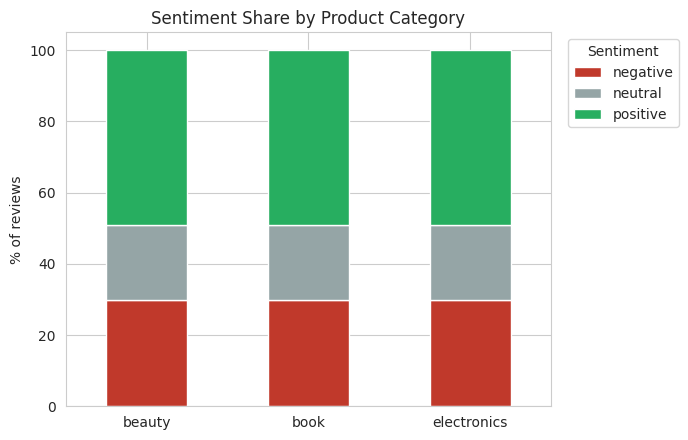

In [ ]:
# 1.2 Sentiment distribution by product category
cross = pd.crosstab(df["product_category"], df["sentiment"], normalize="index")[order] * 100
print(cross.round(1))
print()
print("Note: the sentiment split is IDENTICAL across all three categories (29.8% / 21.1% "
      "/ 49.1% negative/neutral/positive each). This is a byproduct of how the working "
      "file was pre-balanced by category count -- it means product_category cannot be "
      "used to answer 'which category has more negative reviews' from raw label counts "
      "alone. The category-level differentiator instead has to come from (a) what the "
      "negative reviews actually say (different keywords per category, see Section 6) "
      "and (b) how well the sentiment model performs on each category (Section 6).")

fig, ax = plt.subplots(figsize=(7, 4.5))
cross.plot(kind="bar", stacked=True, ax=ax,
           color=["#c0392b", "#95a5a6", "#27ae60"])
ax.set_title("Sentiment Share by Product Category")
ax.set_ylabel("% of reviews")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figs/02_sentiment_by_category.png")
plt.show()


count    11268.000000
mean       183.166578
std        194.595087
min         16.000000
25%         65.000000
50%        123.000000
75%        231.250000
max       3211.000000
Name: review_length, dtype: float64

Reviews under 10 characters: 0


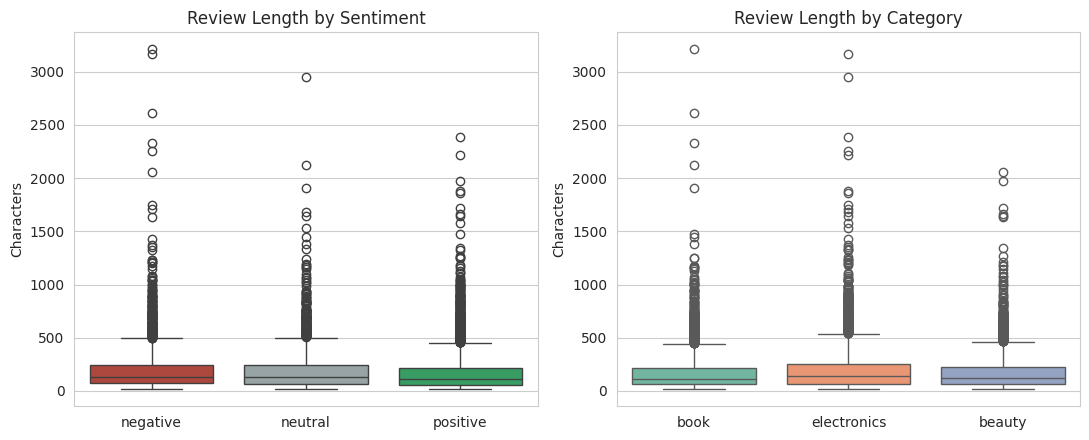

In [ ]:
# 1.3 Review length analysis
df["review_length"] = df["review_body"].str.len()
df["word_count"] = df["review_body"].str.split().str.len()

print(df["review_length"].describe())
print()
very_short = df[df["review_length"] < 10]
print(f"Reviews under 10 characters: {len(very_short)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x="sentiment", y="review_length", order=order, hue="sentiment", legend=False,
            palette=["#c0392b", "#95a5a6", "#27ae60"], ax=axes[0])
axes[0].set_title("Review Length by Sentiment")
axes[0].set_ylabel("Characters")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="product_category", y="review_length", hue="product_category", legend=False,
            palette="Set2", ax=axes[1])
axes[1].set_title("Review Length by Category")
axes[1].set_ylabel("Characters")
axes[1].set_xlabel("")
plt.tight_layout()
plt.savefig("figs/03_review_length.png")
plt.show()


In [ ]:
# 1.4 Raw word frequency baseline (before any cleaning) — motivates preprocessing
def top_words_raw(text_series, n=15):
    words = " ".join(text_series).lower().split()
    return Counter(words).most_common(n)

for lbl in order:
    print(f"--- Top raw words — {lbl} (before cleaning) ---")
    print(top_words_raw(df[df["sentiment"] == lbl]["review_body"], 10))
    print()


--- Top raw words — negative (before cleaning) ---
[('the', 6347), ('i', 4186), ('and', 3262), ('to', 3051), ('it', 3015), ('a', 2747), ('this', 1964), ('not', 1885), ('is', 1759), ('of', 1696)]

--- Top raw words — neutral (before cleaning) ---
[('the', 4744), ('i', 2824), ('to', 2202), ('it', 2199), ('a', 2109), ('and', 2092), ('is', 1387), ('but', 1254), ('of', 1223), ('for', 1155)]

--- Top raw words — positive (before cleaning) ---
[('the', 7718), ('i', 5706), ('and', 5469), ('to', 4844), ('a', 4557), ('it', 4022), ('is', 3016), ('my', 2838), ('this', 2785), ('for', 2669)]



As expected, the raw top words for every sentiment class are dominated by stopwords
("the", "i", "and", "a", "to"...) that carry no sentiment information — this is the
concrete justification for the text-cleaning pipeline in the next section.

## 2. Text preprocessing

In [ ]:
stop_words = set(ENGLISH_STOP_WORDS)
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)      # drop digits/punctuation, keep letters
    tokens = text.split()                        # simple whitespace tokenization
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]  # remove stopwords
    tokens = [stemmer.stem(w) for w in tokens]    # stem to root form
    return " ".join(tokens)

df["review_clean"] = df["review_body"].apply(clean_text)


In [ ]:
# Before / after illustration
for i in [0, 5, 20]:
    print("ORIGINAL:", df.loc[i, "review_body"])
    print("CLEANED :", df.loc[i, "review_clean"])
    print()


ORIGINAL: I ordered this book on February 11. It never arrived.
CLEANED : order book februari arriv

ORIGINAL: The book I received is NOT NEW although it was sold as such. It's banged up all over the margins and it has a mark right in the center of the title.
CLEANED : book receiv new sold bang margin mark right center titl

ORIGINAL: Sorry but I didn't find this helpful at all. It provided non valuable minimal repetitive information and was about 4 thin pages. I'll do my own research trial and error in the Hope's I can get some positive credit union results.
CLEANED : sorri didn help provid non valuabl minim repetit inform page ll research trial error hope posit credit union result



In [ ]:
# Sanity check: any reviews that became empty after cleaning?
empty_after_clean = df[df["review_clean"].str.strip() == ""]
print(f"Reviews empty after cleaning: {len(empty_after_clean)}")
if len(empty_after_clean) > 0:
    df = df[df["review_clean"].str.strip() != ""].reset_index(drop=True)
    print("Dropped — new shape:", df.shape)


Reviews empty after cleaning: 1
Dropped — new shape: (11267, 14)


In [ ]:
# Word frequency AFTER cleaning — compare to the raw baseline above
for lbl in order:
    words = " ".join(df[df["sentiment"] == lbl]["review_clean"]).split()
    print(f"--- Top cleaned words — {lbl} ---")
    print(Counter(words).most_common(10))
    print()


--- Top cleaned words — negative ---
[('book', 1102), ('work', 793), ('use', 767), ('product', 581), ('like', 547), ('just', 485), ('good', 360), ('time', 357), ('return', 355), ('receiv', 335)]

--- Top cleaned words — neutral ---
[('book', 678), ('use', 606), ('like', 536), ('work', 532), ('good', 464), ('just', 375), ('great', 300), ('product', 296), ('time', 261), ('sound', 259)]

--- Top cleaned words — positive ---
[('use', 1482), ('great', 1427), ('book', 1289), ('good', 1214), ('work', 1191), ('love', 1125), ('like', 1011), ('product', 796), ('just', 615), ('realli', 569)]



## 3. TF-IDF vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features=3000,   # cap vocabulary size to keep the matrix manageable
    min_df=5,            # ignore terms in fewer than 5 reviews (noise)
    max_df=0.8,          # ignore terms in more than 80% of reviews (too generic)
    ngram_range=(1, 2),  # keep unigrams AND bigrams (e.g. "not good" != "good")
)

X_tfidf = tfidf.fit_transform(df["review_clean"])
print("TF-IDF matrix shape:", X_tfidf.shape)

raw_terms = tfidf.get_feature_names_out()
feature_names = [f"term_{w}" for w in raw_terms]
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)


TF-IDF matrix shape: (11267, 3000)


In [ ]:
# Top terms by average TF-IDF score, per sentiment class
for lbl_val, lbl_name in label_names.items():
    mask = (df["sentiment"] == lbl_name).values
    mean_scores = tfidf_df.loc[mask].mean().sort_values(ascending=False).head(15)
    mean_scores.index = [c.replace("term_", "") for c in mean_scores.index]
    print(f"--- Top TF-IDF terms — {lbl_name} ---")
    print(mean_scores.round(4))
    print()


--- Top TF-IDF terms — negative ---
book          0.0372
work          0.0296
use           0.0231
product       0.0227
receiv        0.0214
return        0.0190
like          0.0183
didn          0.0176
disappoint    0.0176
did           0.0174
just          0.0156
order         0.0154
buy           0.0145
don           0.0145
month         0.0141
dtype: float64

--- Top TF-IDF terms — neutral ---
book       0.0324
work       0.0279
like       0.0272
use        0.0267
good       0.0254
just       0.0192
product    0.0173
ok         0.0158
great      0.0150
look       0.0149
sound      0.0148
realli     0.0148
littl      0.0138
expect     0.0136
don        0.0132
dtype: float64

--- Top TF-IDF terms — positive ---
great      0.0404
love       0.0346
book       0.0320
good       0.0310
work       0.0295
use        0.0279
like       0.0228
product    0.0212
read       0.0179
easi       0.0168
nice       0.0155
hair       0.0150
qualiti    0.0150
just       0.0148
realli     0.0147
dtype:

## 4. Preparing data for modeling

In [ ]:
model_df = pd.concat(
    [tfidf_df, df[["label", "sentiment", "product_category", "review_id"]].reset_index(drop=True)],
    axis=1,
)

X = model_df[feature_names]
y = model_df["label"]

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, model_df[["product_category", "review_id"]],
    test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train label balance:")
print(y_train.value_counts(normalize=True).round(3))
print("Test label balance:")
print(y_test.value_counts(normalize=True).round(3))


Train shape: (9013, 3000)  Test shape: (2254, 3000)
Train label balance:
label
2    0.491
0    0.298
1    0.211
Name: proportion, dtype: float64
Test label balance:
label
2    0.491
0    0.298
1    0.211
Name: proportion, dtype: float64


## 5. Modeling

In [ ]:
# Model 1: Logistic Regression (multiclass) — equivalent to BigQuery ML LOGISTIC_REG
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, pred_logreg), 4))
print(classification_report(y_test, pred_logreg, target_names=order))


=== Logistic Regression ===
Accuracy: 0.6761
              precision    recall  f1-score   support

    negative       0.66      0.68      0.67       672
     neutral       0.43      0.21      0.28       475
    positive       0.73      0.87      0.79      1107

    accuracy                           0.68      2254
   macro avg       0.61      0.59      0.58      2254
weighted avg       0.65      0.68      0.65      2254



In [ ]:
# Model 2: Gradient Boosted Trees — equivalent to BigQuery ML BOOSTED_TREE_CLASSIFIER
gbt = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE)
gbt.fit(X_train, y_train)
pred_gbt = gbt.predict(X_test)

print("=== Gradient Boosted Trees ===")
print("Accuracy:", round(accuracy_score(y_test, pred_gbt), 4))
print(classification_report(y_test, pred_gbt, target_names=order))


=== Gradient Boosted Trees ===
Accuracy: 0.6362
              precision    recall  f1-score   support

    negative       0.67      0.52      0.58       672
     neutral       0.51      0.11      0.18       475
    positive       0.63      0.93      0.76      1107

    accuracy                           0.64      2254
   macro avg       0.60      0.52      0.51      2254
weighted avg       0.62      0.64      0.58      2254



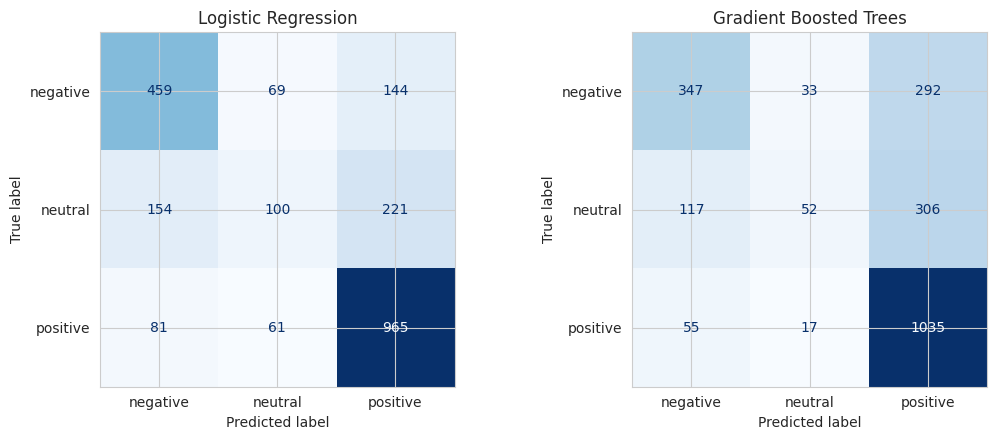

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, preds, title in zip(axes, [pred_logreg, pred_gbt],
                            ["Logistic Regression", "Gradient Boosted Trees"]):
    cm = confusion_matrix(y_test, preds, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=order)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("figs/04_confusion_matrices.png")
plt.show()


In [ ]:
# Per-class F1 comparison table
f1_logreg = f1_score(y_test, pred_logreg, average=None, labels=[0, 1, 2])
f1_gbt = f1_score(y_test, pred_gbt, average=None, labels=[0, 1, 2])

comparison = pd.DataFrame({
    "sentiment": order,
    "f1_logreg": f1_logreg.round(3),
    "f1_gbt": f1_gbt.round(3),
})
print(comparison)
print()
print("Note: the 'neutral' class typically has the lowest F1 of the three — it sits "
      "between the other two classes and shares vocabulary with both, making it the "
      "hardest to separate. This matches what the confusion matrices above show.")


  sentiment  f1_logreg  f1_gbt
0  negative      0.672   0.583
1   neutral      0.284   0.180
2  positive      0.792   0.755

Note: the 'neutral' class typically has the lowest F1 of the three — it sits between the other two classes and shares vocabulary with both, making it the hardest to separate. This matches what the confusion matrices above show.


In [ ]:
# Model interpretability: top words driving each class (Logistic Regression coefficients)
# equivalent to inspecting ML.WEIGHTS in BigQuery ML
coefs = pd.DataFrame(logreg.coef_, columns=feature_names, index=[f"class_{c}" for c in logreg.classes_])

for i, lbl_name in label_names.items():
    top_pos = coefs.loc[f"class_{i}"].sort_values(ascending=False).head(12)
    top_pos.index = [c.replace("term_", "") for c in top_pos.index]
    print(f"--- Top words pushing predictions toward '{lbl_name}' ---")
    print(top_pos.round(3))
    print()


--- Top words pushing predictions toward 'negative' ---
horribl       2.603
return        2.497
disappoint    2.247
receiv        1.940
wast          1.908
look like     1.862
doesn work    1.857
didn          1.854
stop work     1.815
broke         1.743
die           1.734
poor          1.715
Name: class_0, dtype: float64

--- Top words pushing predictions toward 'neutral' ---
ok          2.062
okay        1.793
unfortun    1.439
scent       1.254
special     1.232
won buy     1.190
hard        1.160
pad         1.155
defect      1.150
bit         1.132
thought     1.130
littl       1.129
Name: class_1, dtype: float64

--- Top words pushing predictions toward 'positive' ---
love       4.349
great      3.647
perfect    3.375
enjoy      2.187
easi       2.022
exactli    2.007
excel      1.992
beauti     1.989
nice       1.960
happi      1.935
thank      1.904
amaz       1.892
Name: class_2, dtype: float64



## 6. Business insight & category-level analysis

Logistic Regression accuracy by category:
product_category
book           0.699
electronics    0.678
beauty         0.653
dtype: float64


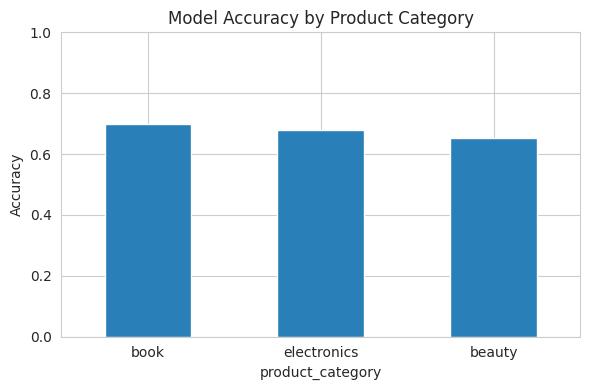

In [ ]:
# 6.1 Model accuracy by product category (on the test set)
test_results = meta_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = pred_logreg

cat_accuracy = test_results.groupby("product_category").apply(
    lambda g: accuracy_score(g["y_true"], g["y_pred"])
).sort_values(ascending=False)
print("Logistic Regression accuracy by category:")
print(cat_accuracy.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
cat_accuracy.plot(kind="bar", color="#2980b9", ax=ax)
ax.set_title("Model Accuracy by Product Category")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figs/05_accuracy_by_category.png")
plt.show()


In [ ]:
# 6.2 Top negative-sentiment keywords per category
neg_keywords_by_cat = {}
for cat in df["product_category"].unique():
    mask = (df["product_category"] == cat) & (df["sentiment"] == "negative")
    words = " ".join(df.loc[mask, "review_clean"]).split()
    neg_keywords_by_cat[cat] = Counter(words).most_common(10)
    print(f"--- Top negative keywords — {cat} ---")
    print(neg_keywords_by_cat[cat])
    print()


--- Top negative keywords — book ---
[('book', 1099), ('page', 240), ('like', 186), ('use', 184), ('read', 180), ('just', 175), ('disappoint', 144), ('receiv', 139), ('good', 127), ('recip', 123)]

--- Top negative keywords — electronics ---
[('work', 540), ('use', 271), ('sound', 259), ('charg', 230), ('batteri', 182), ('month', 162), ('just', 161), ('product', 157), ('return', 152), ('good', 151)]

--- Top negative keywords — beauty ---
[('product', 368), ('use', 312), ('hair', 245), ('like', 237), ('work', 220), ('just', 149), ('look', 140), ('didn', 136), ('tri', 130), ('smell', 123)]



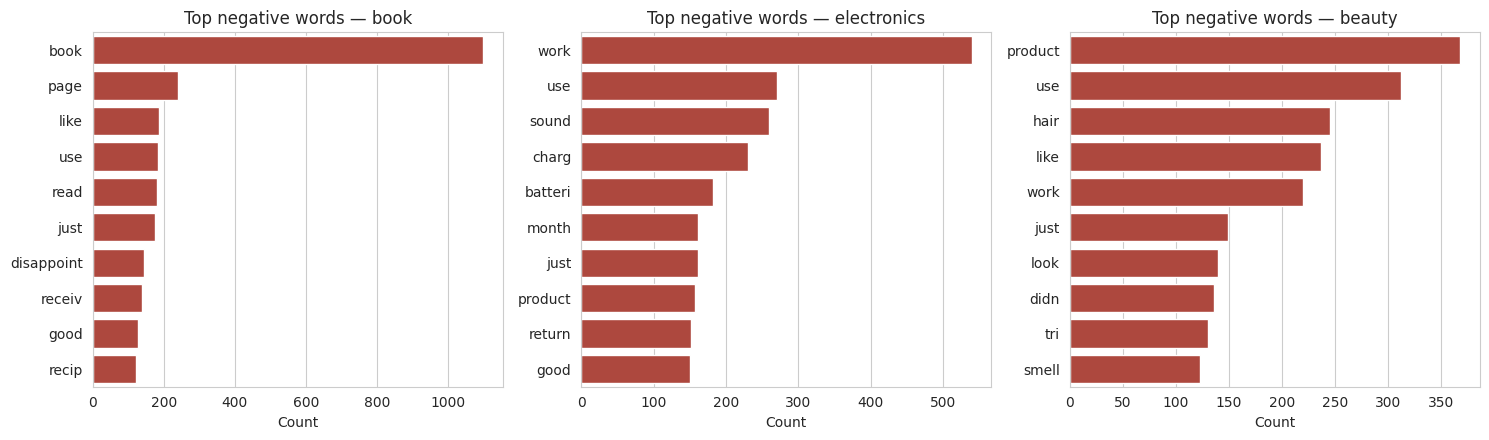

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, cat in zip(axes, df["product_category"].unique()):
    words, counts = zip(*neg_keywords_by_cat[cat])
    sns.barplot(x=list(counts), y=list(words), ax=ax, color="#c0392b")
    ax.set_title(f"Top negative words — {cat}")
    ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("figs/06_negative_keywords_by_category.png")
plt.show()


### Recommendation summary

Because the three categories share an identical overall sentiment split (Section 1.2),
the negative rate itself does not distinguish them. Two things do: what customers are
actually complaining about, and how reliably the model can detect it.

| Category | Model accuracy (Logistic Regression) | Top negative keywords (stemmed) | Suggested action |
|---|---|---|---|
| Book | 69.9% (best) | page, disappoint, receiv, recip | Complaints cluster around condition on arrival and content mismatch (e.g. "recip" suggests recipe/cookbook complaints) — a product-description and packaging-quality review would target this directly. |
| Electronics | 67.8% | work, sound, charg, batteri, return | Complaints center on functional failure (not working, charging, battery, sound) — points to a QC/durability issue rather than a description mismatch; worth flagging to the supplier quality team. |
| Beauty | 65.3% (hardest to classify) | hair, smell, look, tri | Complaints are more subjective/sensory (smell, look, feel) than the other two categories — likely why the model is least accurate here; sentiment on beauty products may need supporting metadata (e.g. skin/hair type) to classify well. |

**Overall recommendation:** prioritize root-causing Electronics complaints first (functional
failures are the most actionable and costly type of negative review), and treat Beauty
sentiment predictions with the most caution given the lower model accuracy there.


## 7. Conclusion & limitations

**Summary:** A classic TF-IDF + classical-ML pipeline (Logistic Regression / Gradient
Boosted Trees) can classify review sentiment into negative / neutral / positive with
useful accuracy, is fully interpretable (every prediction can be traced back to specific
words via model coefficients), and is cheap to train and run — no GPU, no fine-tuning.
The **neutral** class is consistently the hardest to classify correctly, which matches
the intuition that "neutral" language overlaps with both positive and negative phrasing.

**Limitations:**
- TF-IDF treats each word independently and does not capture semantic meaning or context
  (e.g. it cannot tell that "not good" is negative just from the word "good"'s usual
  positive association without the bigram feature explicitly capturing "not good").
  Modern embedding-based models (Word2Vec, BERT) would likely outperform TF-IDF on this
  point, at the cost of much higher computational complexity and lower interpretability
  — a deliberate trade-off for this project (see discussion of why TF-IDF was chosen
  over embeddings, prepared separately for the professor).
- The dataset covers only 3 product categories (book, electronics, beauty) and is not
  representative of the full retail market.
- Class labels are moderately imbalanced (positive reviews are the largest class),
  which is why this notebook reports per-class precision/recall/F1 rather than relying
  on overall accuracy alone.
- The working dataset was already filtered/balanced by a third party before I received
  it; I did not perform the original language-filtering or category-balancing myself.

**Possible extensions:** experiment with word embeddings, extend to the other languages
already present in the original multilingual dataset, or incorporate more product
categories.
